In [148]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from sklearn.preprocessing import normalize
from typing import List, Dict

http://www.eionet.europa.eu/gemet/concept/8366 -> temperature

https://data.geoscience.earth/ncl/ISO11074v2025/3.253 -> LOES

The temperature in degrees Celsius used for measuring Loss-on-Ignition (LOI), which is a method for determining soil organic matter content.

In [174]:
query="LOI_method"
definition="The temperature in degrees Celsius used for measuring Loss-on-Ignition (LOI), which is a method for determining soil organic matter content."
sentence = f"{query} {definition}"

t1_query = "LOEC"
t1_definition = "['lowest \n test substance \n concentration \n  that has a statistically significant effect (\n p\n \xa0>\xa00,05)']"

t2_query = "temperature"
t2_definition = "A property that determines the direction of heat flow when an object is brought into thermal contact with other objects: heat flows from regions of higher to those of lower temperatures."

In [186]:
import spacy

In [198]:
# Load the English model
nlp = spacy.load("en_core_web_sm")


doc = nlp(definition)

# Example: Finding relative clauses (relcl) and their heads
for token in doc:
    if token.dep_ == "relcl":
        # Extract the clause subtree
        clause = "".join([t.text_with_ws for t in token.subtree])
        print(f"Relative Clause: {clause}")


Relative Clause: Celsius used for measuring Loss-on-Ignition (LOI), which is a method for determining soil organic matter content
Relative Clause: which is a method for determining soil organic matter content


In [199]:
spacy.displacy.serve(doc, style="dep")


Using the 'dep' visualizer
Serving on http://0.0.0.0:5000 ...

Shutting down server on port 5000.


In [150]:
def load_vocab_indexes(modelname="all-MiniLM-L6-v2"):
    """Load FAISS indexes and associated metadata."""

        
    # Loading in FAISS indexes of preprocessed vocab embeddings
    index_lib = faiss.read_index(f"data/vocabCombined-{modelname.replace('/','--')}.index")

    # Loading library
    meta_data_lib = np.load(
        f"data/vocabCombined-{modelname.replace('/','--')}-meta.npz", allow_pickle=True
    )
    # Retrieving dictionairy with key index ID corresponding FAISS index
    meta_data_dict = meta_data_lib["id_to_meta"].item()


    return index_lib, meta_data_dict

In [151]:

def incremental_queries_with_word(sentence: str):
    words = sentence.split()
    results = []

    for i in range(len(words)):
        results.append({
            "query": " ".join(words[: i + 1]),
            "added_word": words[i],
        })

    return results


In [152]:
def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    a = a / np.linalg.norm(a)
    b = b / np.linalg.norm(b)
    return 1.0 - np.dot(a, b)


In [153]:
modelname = "models_local/all-MiniLM-L6-v2"
model = SentenceTransformer(modelname)

In [154]:

def embed_text(model, text: str) -> np.ndarray:
    emb = model.encode(
        [text],
        normalize_embeddings=True
    )
    return emb[0].astype("float32")


In [155]:
def embed_vocab(word, definition=None, alpha=0.4):
    # encode separately
    emb_word = model.encode(word, normalize_embeddings=True)
    
    # definition embedding
    if definition and isinstance(definition, str) and definition.strip() and definition.lower() != 'nan':
        emb_def = model.encode(definition, normalize_embeddings=True)
    elif isinstance(definition, list) and len(definition) > 0:
        emb_def_list = model.encode(definition, normalize_embeddings=True)
        emb_def = emb_def_list.mean(axis=0)
    else:
        emb_def = emb_word
    
    # weighted combination
    vec = alpha * emb_word + (1 - alpha) * emb_def
    vec = normalize(vec.reshape(1, -1)).squeeze()
    return alpha * emb_word + (1 - alpha) * emb_def


In [156]:

def faiss_top1(index, query_emb: np.ndarray):
    q = np.asarray(query_emb)

    # Allow (d,), (1,d), or (n,d)
    if q.ndim == 1:
        q = q.reshape(1, -1)
    elif q.ndim == 2:
        pass
    else:
        # squeeze common accidental extra dims like (1,1,d)
        q = np.squeeze(q)
        if q.ndim == 1:
            q = q.reshape(1, -1)
        elif q.ndim != 2:
            raise ValueError(f"query_emb must be 1D or 2D after squeeze, got shape={np.asarray(query_emb).shape}")

    # FAISS wants contiguous float32
    q = np.ascontiguousarray(q.astype("float32"))

    D, I = index.search(q, k=1)
    faiss_id = int(I[0, 0])
    score = float(D[0, 0])

    # Reconstruct the stored vector for that id (if supported by your index type)
    vec = index.reconstruct(faiss_id)

    return faiss_id, vec, score



In [157]:

def rank_and_distance(index, query_emb, target_id, k=100):
    q = np.asarray(query_emb, dtype="float32").reshape(1, -1)
    D, I = index.search(q, k)

    ids = I[0].tolist()
    dists = D[0].tolist()

    if target_id in ids:
        pos = ids.index(target_id)
        return pos, float(dists[pos])
    else:
        return None, np.inf


In [158]:

def top1(index, query_emb):
    q = np.asarray(query_emb, dtype="float32").reshape(1, -1)
    D, I = index.search(q, 1)
    return int(I[0, 0]), float(D[0, 0])


In [159]:
def incremental_loi_experiment(
    sentence: str,
    t1_id: int,
    t2_id: int,
    model,
    index,
    meta,
    k_probe: int = 100,
):
    results = []

    for step, item in enumerate(incremental_queries_with_word(sentence), start=1):
        
        q = item["query"]
        added_word = item["added_word"]

        q_emb = embed_text(model, q)

        top_id, top_dist = top1(index, q_emb)

        r1, d1 = rank_and_distance(index, q_emb, t1_id, k_probe)
        r2, d2 = rank_and_distance(index, q_emb, t2_id, k_probe)

        results.append({
            "step": step,
            "query": q,
            "added_word": added_word,
            "top_label": meta[top_id].get("label"),
            "top_dist": top_dist,

            "t1_rank": r1,
            "t1_dist": d1,
            "t1_label": meta[t1_id].get("label"),

            "t2_rank": r2,
            "t2_dist": d2,
            "t2_label": meta[t2_id].get("label"),

            "winner": (
                "temperature (t2)" if d2 < d1 else
                "LOEC (t1)" if d1 < d2 else
                "tie"
            )
        })

    return results

In [160]:

index_vocabs, dict_vocabs = load_vocab_indexes(modelname = modelname)

In [161]:
# q_emb = embed_vocab(query, definition).astype("float32").reshape(1, -1)
t1_emb=embed_vocab(t1_query, t1_definition).astype("float32").reshape(1, -1)
t2_emb=embed_vocab(t2_query, t2_definition).astype("float32").reshape(1, -1)

In [162]:

def faiss_top1_distance(index, query_emb: np.ndarray):
    q = np.asarray(query_emb, dtype="float32")
    if q.ndim == 1:
        q = q.reshape(1, -1)

    D, I = index.search(q, k=1)
    return int(I[0, 0]), float(D[0, 0])


In [163]:
expected_id, _ = faiss_top1_distance(index_vocabs, t2_emb)
end_favorit_id, _ = faiss_top1_distance(index_vocabs, t1_emb)


In [164]:

results = incremental_loi_experiment(
    sentence=sentence,
    t1_id=end_favorit_id,
    t2_id=expected_id,
    model=model,
    index=index_vocabs,
    meta=dict_vocabs
)


In [165]:
sentence


'LOI method The temperature in degrees Celsius used for measuring Loss-on-Ignition , which is a method for determining soil organic matter content.'

In [166]:

import pandas as pd

df = pd.DataFrame(results)
df


,step,query,added_word,top_label,top_dist,t1_rank,t1_dist,t1_label,t2_rank,t2_dist,t2_label,winner
0,1,LOI,LOI,LoRa,0.442396,1,0.602094,LOEC,NaN,inf,temperature,LOEC (t1)
1,2,LOI method,method,method,0.832609,1,0.843683,LOEC,NaN,inf,temperature,LOEC (t1)
2,3,LOI method The,The,LoRa,0.775398,2,0.790137,LOEC,NaN,inf,temperature,LOEC (t1)
3,4,LOI method The temperature,temperature,temperature,0.846463,11,1.043210,LOEC,0.0,0.846463,temperature,temperature (t2)
4,5,LOI method The temperature in,in,temperature,0.841588,11,1.053066,LOEC,0.0,0.841588,temperature,temperature (t2)
5,6,LOI method The temperature in degrees,degrees,temperature,0.811920,25,1.100645,LOEC,0.0,0.811920,temperature,temperature (t2)
6,7,LOI method The temperature in degrees Celsius,Celsius,temperature,0.848351,14,1.078637,LOEC,0.0,0.848351,temperature,temperature (t2)
7,8,LOI method The temperature in degrees Celsius ...,used,temperature,0.923918,11,1.084363,LOEC,0.0,0.923918,temperature,temperature (t2)
8,9,LOI method The temperature in degrees Celsius ...,for,thermal method,0.939292,9,1.091710,LOEC,1.0,0.944188,temperature,temperature (t2)
9,10,LOI method The temperature in degrees Celsius ...,measuring,temperature measurement,0.790499,17,1.105870,LOEC,1.0,0.918687,temperature,temperature (t2)


In [167]:
df[[
    "added_word",
    "top_label",
    "t1_rank",
    "t2_rank",
    "t1_dist",
    "t2_dist",
    "winner"
]]

,added_word,top_label,t1_rank,t2_rank,t1_dist,t2_dist,winner
0,LOI,LoRa,1,NaN,0.602094,inf,LOEC (t1)
1,method,method,1,NaN,0.843683,inf,LOEC (t1)
2,The,LoRa,2,NaN,0.790137,inf,LOEC (t1)
3,temperature,temperature,11,0.0,1.043210,0.846463,temperature (t2)
4,in,temperature,11,0.0,1.053066,0.841588,temperature (t2)
5,degrees,temperature,25,0.0,1.100645,0.811920,temperature (t2)
6,Celsius,temperature,14,0.0,1.078637,0.848351,temperature (t2)
7,used,temperature,11,0.0,1.084363,0.923918,temperature (t2)
8,for,thermal method,9,1.0,1.091710,0.944188,temperature (t2)
9,measuring,temperature measurement,17,1.0,1.105870,0.918687,temperature (t2)


<Axes: title={'center': 'Distance evolution during incremental query expansion'}, xlabel='step'>

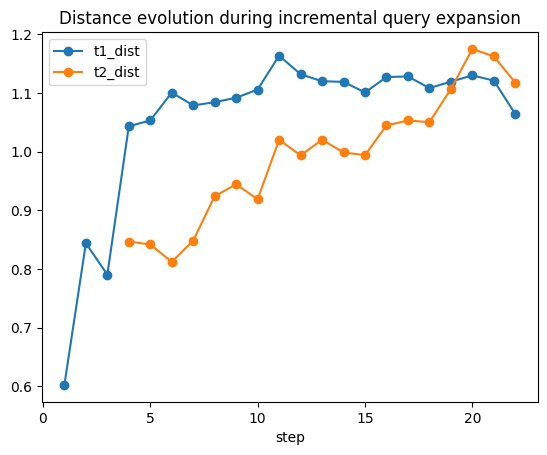

In [168]:



df.plot(
    x="step",
    y=["t1_dist", "t2_dist"],
    marker="o",
    title="Distance evolution during incremental query expansion"
)

